# 05 — Ablation analysis
Compare all training runs against the baseline.
Run this notebook after checkpoints exist for each run.

Runs included:
- `runs/baseline/`        — YOLOv8n, SGD, default augmentation
- `runs/arch_only/`       — Modified neck (partial transfer, v1 — expected worse)
- `runs/train_only/`      — AdamW + imgsz768 + MixUp (v1 — expected worse)
- `runs/arch_only_v2/`    — Frozen backbone (v2 — expected better)
- `runs/train_only_v2/`   — Cosine LR + HSV + scale jitter (v2 — expected better)
- `runs/combined_v2/`     — Frozen backbone + v2 training strategy (expected best)


## 0. Setup

In [1]:
import json
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO
%matplotlib inline

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 2080 SUPER


In [2]:
PROJECT_ROOT  = Path("..").resolve()
DATA_YAML     = str(PROJECT_ROOT / "data" / "coco_subset.yaml")
RESULTS_DIR   = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

VAL_IMAGES    = PROJECT_ROOT / "data" / "coco_subset" / "images" / "val"

CHECKPOINTS = {
    "baseline":       PROJECT_ROOT / "results" / "baseline"       / "baseline_coco_eval.json",
    "arch_only":      PROJECT_ROOT / "results" / "arch_only"      / "arch_only_coco_eval.json",
    "train_only":     PROJECT_ROOT / "results" / "train_only"     / "train_only_coco_eval.json",
    "arch_only_v2":   PROJECT_ROOT / "results" / "arch_only_v2"   / "arch_only_v2_coco_eval.json",
    "train_only_v2":  PROJECT_ROOT / "results" / "train_only_v2"  / "train_only_v2_coco_eval.json",
    "combined_v2":    PROJECT_ROOT / "results" / "combined_v2"    / "combined_v2_coco_eval.json",
}

WEIGHTS = {
    "baseline":       PROJECT_ROOT / "runs" / "baseline"       / "weights" / "best.pt",
    "arch_only":      PROJECT_ROOT / "runs" / "arch_only"      / "weights" / "best.pt",
    "train_only":     PROJECT_ROOT / "runs" / "train_only"     / "weights" / "best.pt",
    "arch_only_v2":   PROJECT_ROOT / "runs" / "arch_only_v2"   / "weights" / "best.pt",
    "train_only_v2":  PROJECT_ROOT / "runs" / "train_only_v2"  / "weights" / "best.pt",
    "combined_v2":    PROJECT_ROOT / "runs" / "combined_v2"    / "weights" / "best.pt",
}

RESULTS_CSVS = {
    "baseline":       PROJECT_ROOT / "runs" / "baseline"       / "results.csv",
    "arch_only":      PROJECT_ROOT / "runs" / "arch_only"      / "results.csv",
    "train_only":     PROJECT_ROOT / "runs" / "train_only"     / "results.csv",
    "arch_only_v2":   PROJECT_ROOT / "runs" / "arch_only_v2"   / "results.csv",
    "train_only_v2":  PROJECT_ROOT / "runs" / "train_only_v2"  / "results.csv",
    "combined_v2":    PROJECT_ROOT / "runs" / "combined_v2"    / "results.csv",
}

# Evaluation imgsz per run — must match training imgsz
EVAL_IMGSZ = {
    "baseline":       640,
    "arch_only":      640,
    "train_only":     768,   # trained at 768
    "arch_only_v2":   640,
    "train_only_v2":  640,
    "combined_v2":    640,
}

# Check what's available
for name, path in WEIGHTS.items():
    status = "OK" if path.exists() else f"MISSING — {path}"
    print(f"{name:<16} weights: {status}")


baseline         weights: OK
arch_only        weights: OK
train_only       weights: OK
arch_only_v2     weights: OK
train_only_v2    weights: OK
combined_v2      weights: OK


## 1. Run evaluation on all checkpoints
Skip runs that already have a saved JSON in results/.

In [3]:
def evaluate_run(name, weights_path, out_path, imgsz=640):
    """Evaluate a checkpoint and save metrics to JSON. Skips if JSON already exists."""
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.exists():
        print(f"[{name}] Already evaluated — loading {out_path.name}")
        with open(out_path) as f:
            return json.load(f)

    if not weights_path.exists():
        print(f"[{name}] SKIPPED — weights not found at {weights_path}")
        return None

    print(f"\n[{name}] Evaluating {weights_path} (imgsz={imgsz}) ...")
    model   = YOLO(str(weights_path))
    metrics = model.val(data=DATA_YAML, imgsz=imgsz, verbose=False)

    result = {
        "mAP50":     round(float(metrics.box.map50), 4),
        "mAP50_95":  round(float(metrics.box.map),   4),
        "precision": round(float(metrics.box.mp),    4),
        "recall":    round(float(metrics.box.mr),    4),
        "per_class": {
            model.names[i]: round(float(v), 4)
            for i, v in enumerate(metrics.box.maps)
        },
    }

    with open(out_path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"[{name}] mAP50={result['mAP50']}  mAP50-95={result['mAP50_95']}  → saved {out_path.name}")
    return result


all_metrics = {}
for name in WEIGHTS:
    imgsz = EVAL_IMGSZ.get(name, 640)
    all_metrics[name] = evaluate_run(
        name,
        WEIGHTS[name],
        CHECKPOINTS[name],
        imgsz=imgsz,
    )

# Drop runs that haven't been trained yet
all_metrics = {k: v for k, v in all_metrics.items() if v is not None}
print(f"\nAvailable runs: {list(all_metrics.keys())}")


[baseline] Already evaluated — loading baseline_coco_eval.json
[arch_only] Already evaluated — loading arch_only_coco_eval.json
[train_only] Already evaluated — loading train_only_coco_eval.json

[arch_only_v2] Evaluating /home/paul/Desktop/projects/deep-learning/homework2/runs/arch_only_v2/weights/best.pt (imgsz=640) ...
Ultralytics 8.4.35 🚀 Python-3.13.12 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 SUPER, 7782MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3063.9±566.8 MB/s, size: 144.3 KB)
val: Scanning /home/paul/Desktop/projects/deep-learning/homework2/data/coco_subset/labels/val.cache... 600 images, 1005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1600/1600 516.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 12.6it/s 8.0s.1s
                   all       1600       4169      0.272      0.391       0.23       0.1

## 2. Summary comparison table
The headline numbers for your README.

In [4]:
rows = []
for name, m in all_metrics.items():
    baseline = all_metrics.get("baseline", {})
    delta_map50    = round(m["mAP50"]    - baseline.get("mAP50", m["mAP50"]), 4)
    delta_map5095  = round(m["mAP50_95"] - baseline.get("mAP50_95", m["mAP50_95"]), 4)
    rows.append({
        "Run":         name,
        "mAP@0.5":     m["mAP50"],
        "mAP@0.5:0.95":m["mAP50_95"],
        "Precision":   m["precision"],
        "Recall":      m["recall"],
        "ΔmAP50":      f"+{delta_map50}" if delta_map50 >= 0 else str(delta_map50),
        "ΔmAP50-95":   f"+{delta_map5095}" if delta_map5095 >= 0 else str(delta_map5095),
    })

df_summary = pd.DataFrame(rows).set_index("Run")
print(df_summary.to_string())

# Save as CSV for the README
df_summary.to_csv(RESULTS_DIR / "summary_table.csv")
print(f"\nSaved → {RESULTS_DIR / 'summary_table.csv'}")

               mAP@0.5  mAP@0.5:0.95  Precision  Recall   ΔmAP50 ΔmAP50-95
Run                                                                       
baseline        0.1964        0.1355     0.2599  0.3336     +0.0      +0.0
arch_only       0.0540        0.0329     0.2339  0.0900  -0.1424   -0.1026
train_only      0.1219        0.0811     0.1867  0.2168  -0.0745   -0.0544
arch_only_v2    0.2297        0.1600     0.2716  0.3907  +0.0333   +0.0245
train_only_v2   0.1934        0.1339     0.2465  0.3241   -0.003   -0.0016
combined_v2     0.2319        0.1618     0.2754  0.3923  +0.0355   +0.0263

Saved → /home/paul/Desktop/projects/deep-learning/homework2/results/summary_table.csv


## 3. mAP bar chart — before vs after

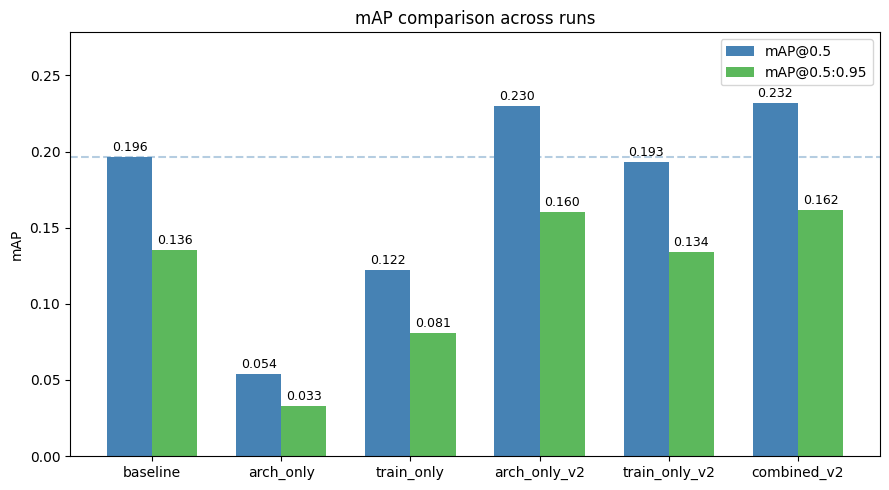

Saved → results/map_comparison.png


In [5]:
run_names  = list(all_metrics.keys())
map50      = [all_metrics[r]["mAP50"]    for r in run_names]
map5095    = [all_metrics[r]["mAP50_95"] for r in run_names]

x     = np.arange(len(run_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, map50,   width, label="mAP@0.5",     color="steelblue")
bars2 = ax.bar(x + width/2, map5095, width, label="mAP@0.5:0.95",color="#5cb85c")

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(run_names)
ax.set_ylabel("mAP")
ax.set_title("mAP comparison across runs")
ax.legend()
ax.set_ylim(0, max(map50) * 1.2)

# Baseline reference line
if "baseline" in all_metrics:
    ax.axhline(all_metrics["baseline"]["mAP50"], linestyle="--", color="steelblue",
               alpha=0.4, label="baseline mAP@0.5")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "map_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/map_comparison.png")

## 4. Training curves — all runs overlaid
Shows convergence speed and stability differences across runs.

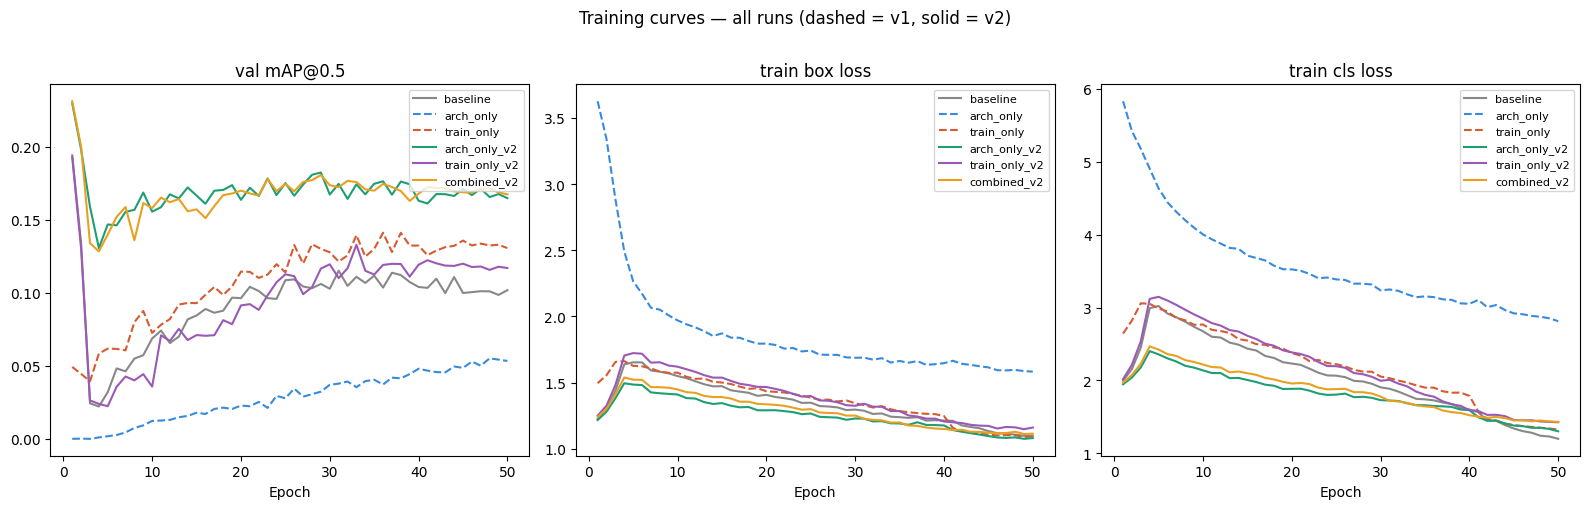

Saved → results/all_training_curves.png


In [6]:
COLORS = {
    "baseline":       "#888888",
    "arch_only":      "#378ADD",
    "train_only":     "#D85A30",
    "arch_only_v2":   "#1D9E75",
    "train_only_v2":  "#9B59B6",
    "combined_v2":    "#E8A020",
}

# v1 runs drawn dashed, v2 runs solid
DASHED = {"arch_only", "train_only"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [
    ("metrics/mAP50(B)",    "val mAP@0.5"),
    ("train/box_loss",      "train box loss"),
    ("train/cls_loss",      "train cls loss"),
]

for ax, (col, title) in zip(axes, metrics_to_plot):
    for name, csv_path in RESULTS_CSVS.items():
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        if col not in df.columns:
            continue
        linestyle = "--" if name in DASHED else "-"
        ax.plot(df["epoch"], df[col],
                label=name, color=COLORS.get(name, "gray"),
                linewidth=1.5, linestyle=linestyle)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)

plt.suptitle("Training curves — all runs (dashed = v1, solid = v2)", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "all_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/all_training_curves.png")


## 5. Precision-Recall comparison
Scatter plot of all runs in P/R space — shows trade-off clearly.

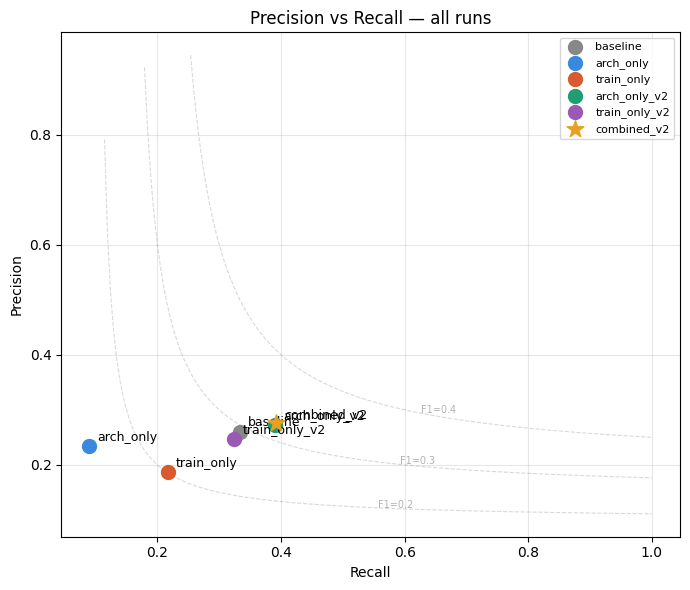

Saved → results/precision_recall_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, m in all_metrics.items():
    color  = COLORS.get(name, "gray")
    marker = "*" if name == "combined_v2" else "o"
    size   = 160 if name == "combined_v2" else 100
    ax.scatter(m["recall"], m["precision"],
               color=color, s=size, marker=marker,
               zorder=3, label=name)
    ax.annotate(name, (m["recall"], m["precision"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision vs Recall — all runs")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Iso-F1 curves
r_range = np.linspace(0.01, 1.0, 200)
for f1 in [0.2, 0.3, 0.4]:
    p_vals = f1 * r_range / (2 * r_range - f1)
    mask   = (p_vals > 0) & (p_vals <= 1)
    ax.plot(r_range[mask], p_vals[mask], "--", color="gray",
            alpha=0.3, linewidth=0.8)
    mid = len(r_range[mask]) // 2
    if mid > 0:
        ax.text(r_range[mask][mid], p_vals[mask][mid],
                f"F1={f1}", fontsize=7, color="gray", alpha=0.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "precision_recall_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/precision_recall_scatter.png")


## 7. Side-by-side prediction comparison
Same val images run through baseline and best run — visually shows the improvement.

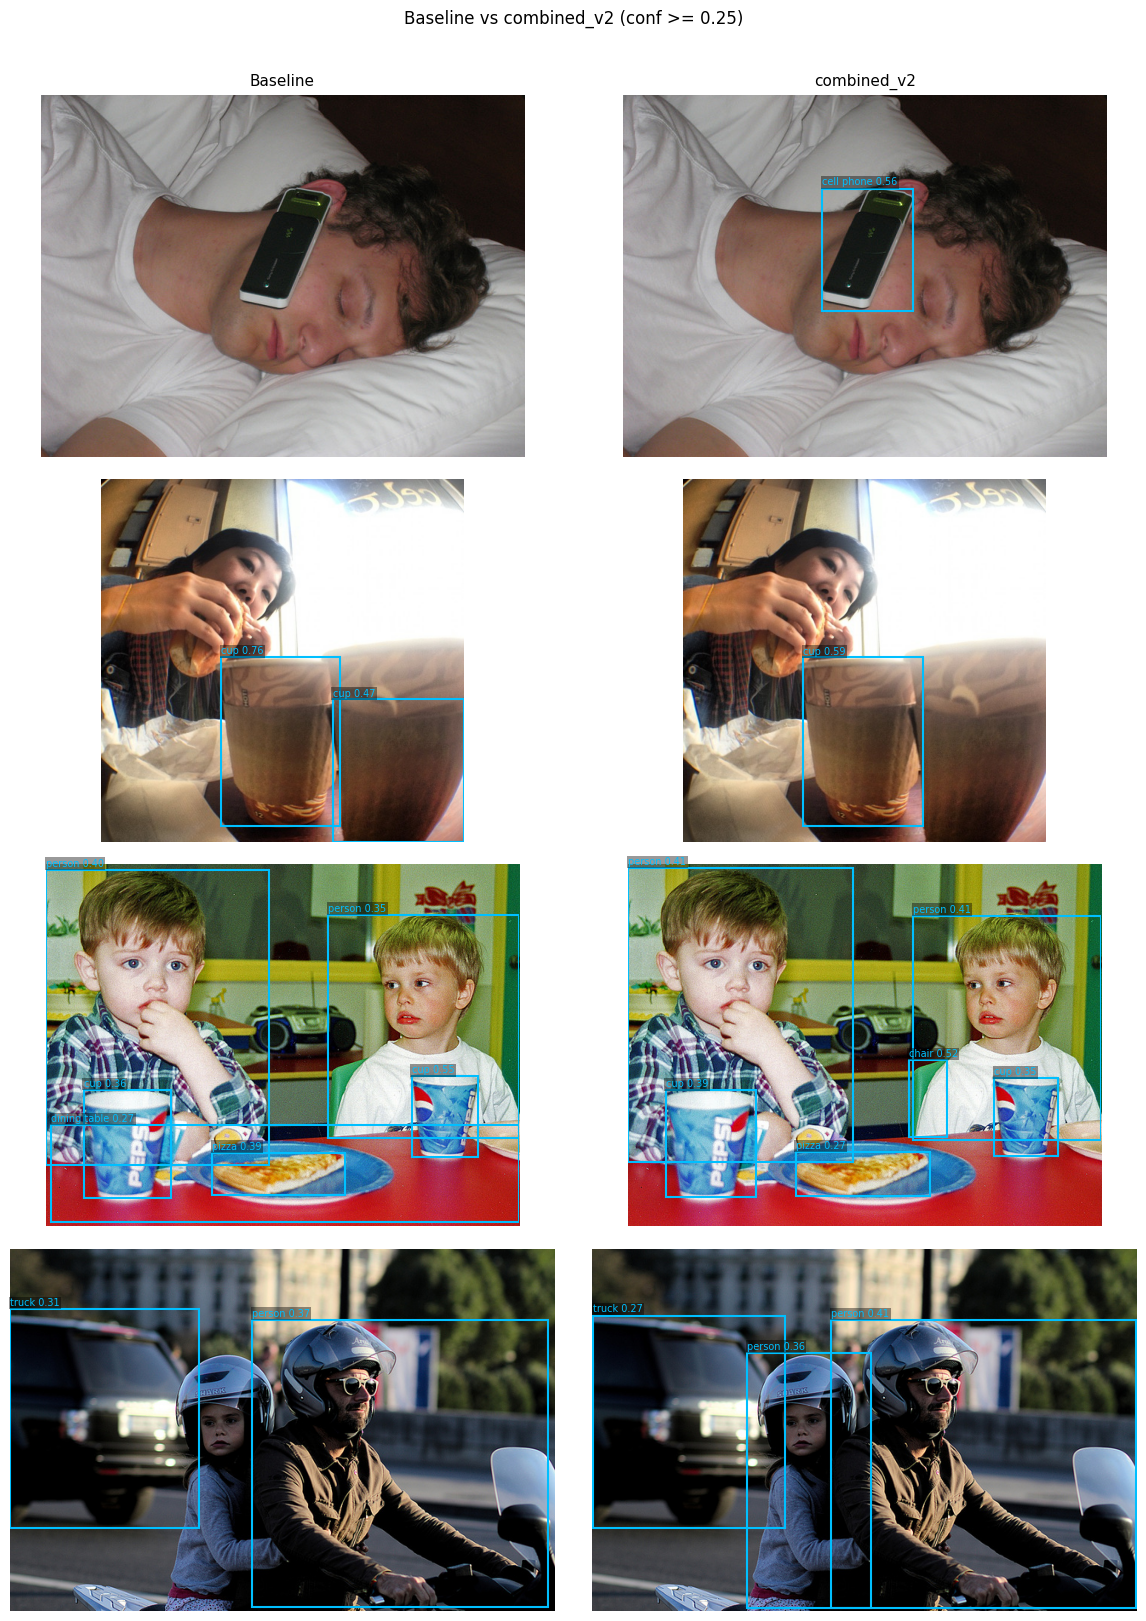

Saved → results/side_by_side_predictions.png


In [9]:
CONF_THRESH = 0.25
N_IMGS      = 4

compare_run = "combined_v2" if "combined_v2" in all_metrics else \
              max((r for r in all_metrics if r != "baseline"),
                  key=lambda r: all_metrics[r]["mAP50_95"], default=None)

if compare_run is None or "baseline" not in all_metrics:
    print("Need at least baseline + one other run for side-by-side comparison.")
else:
    model_baseline = YOLO(str(WEIGHTS["baseline"]))
    model_modified = YOLO(str(WEIGHTS[compare_run]))

    val_imgs = sorted(VAL_IMAGES.glob("*.jpg"))
    sample   = random.sample(val_imgs, min(N_IMGS, len(val_imgs)))

    def draw_boxes(ax, img_path, model, conf):
        result = model.predict(str(img_path), conf=conf, verbose=False)[0]
        img    = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            c   = float(box.conf[0])
            cls = int(box.cls[0])
            lbl = f"{model.names[cls]} {c:.2f}"
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=1.5, edgecolor="#00bfff", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1-4, lbl, fontsize=7, color="#00bfff",
                    bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))

    fig, axes = plt.subplots(N_IMGS, 2, figsize=(12, N_IMGS * 4))
    axes[0, 0].set_title("Baseline",     fontsize=11)
    axes[0, 1].set_title(compare_run,    fontsize=11)

    for row, img_path in enumerate(sample):
        draw_boxes(axes[row, 0], img_path, model_baseline, CONF_THRESH)
        draw_boxes(axes[row, 1], img_path, model_modified, CONF_THRESH)
        axes[row, 0].set_ylabel(img_path.name, fontsize=7)

    plt.suptitle(f"Baseline vs {compare_run} (conf >= {CONF_THRESH})", y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "side_by_side_predictions.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → results/side_by_side_predictions.png")

## 8. Final summary for README
Copy-paste ready table.

In [10]:
baseline = all_metrics.get("baseline", {})

print("=" * 68)
print(f"{'Run':<14} {'mAP@0.5':>9} {'mAP@0.5:0.95':>13} {'Precision':>10} {'Recall':>8}")
print("-" * 68)

for name, m in all_metrics.items():
    d50   = m['mAP50']    - baseline.get('mAP50', m['mAP50'])
    d5095 = m['mAP50_95'] - baseline.get('mAP50_95', m['mAP50_95'])
    d50_s   = f"({'+' if d50   >= 0 else ''}{d50:.3f})" if name != "baseline" else ""
    d5095_s = f"({'+' if d5095 >= 0 else ''}{d5095:.3f})" if name != "baseline" else ""
    print(f"{name:<14} {m['mAP50']:>9.4f} {m['mAP50_95']:>13.4f} {m['precision']:>10.4f} {m['recall']:>8.4f}  {d50_s} {d5095_s}")

print("=" * 68)

if len(all_metrics) > 1:
    best_run = max(all_metrics, key=lambda r: all_metrics[r]["mAP50_95"])
    best     = all_metrics[best_run]
    print(f"\nBest run     : {best_run}")
    print(f"mAP50 gain   : {best['mAP50']    - baseline.get('mAP50', 0):+.4f}")
    print(f"mAP50-95 gain: {best['mAP50_95'] - baseline.get('mAP50_95', 0):+.4f}")

Run              mAP@0.5  mAP@0.5:0.95  Precision   Recall
--------------------------------------------------------------------
baseline          0.1964        0.1355     0.2599   0.3336   
arch_only         0.0540        0.0329     0.2339   0.0900  (-0.142) (-0.103)
train_only        0.1219        0.0811     0.1867   0.2168  (-0.074) (-0.054)
arch_only_v2      0.2297        0.1600     0.2716   0.3907  (+0.033) (+0.024)
train_only_v2     0.1934        0.1339     0.2465   0.3241  (-0.003) (-0.002)
combined_v2       0.2319        0.1618     0.2754   0.3923  (+0.036) (+0.026)

Best run     : combined_v2
mAP50 gain   : +0.0355
mAP50-95 gain: +0.0263
